In [1]:
import shap
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append("../src")
from feature_extraction.audio_features import extract_features

/Users/aadiii/Desktop/PulseIQ-AI/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
pk_model   = joblib.load("../models/parkinsons_model.pkl")
pk_imputer = joblib.load("../models/parkinsons_imputer.pkl")

resp_model   = joblib.load("../models/respiratory_model.pkl")
resp_imputer = joblib.load("../models/respiratory_imputer.pkl")

print("✅ Models loaded")

✅ Models loaded


In [3]:
stress_model = joblib.load("../models/stress_model.pkl")
depr_model   = joblib.load("../models/depression_model.pkl")

In [4]:
pk_feature_cols = ["pitch", "hnr", "jitter", "shimmer", "nhr", "rpde", "dfa"]

# Load training data to build explainer
df_pk = pd.read_csv("../data/parkinsons_tabular/parkinsons.csv")
df_pk = df_pk.rename(columns={
    "MDVP:Fo(Hz)": "pitch",
    "HNR": "hnr",
    "MDVP:Jitter(Abs)": "jitter",
    "MDVP:Shimmer": "shimmer",
    "NHR": "nhr",
    "RPDE": "rpde",
    "DFA": "dfa"
})

X_pk = df_pk[pk_feature_cols]
X_pk_imp = pk_imputer.transform(X_pk)
X_pk_imp_df = pd.DataFrame(X_pk_imp, columns=pk_feature_cols)

# Build SHAP explainer
pk_explainer = shap.TreeExplainer(pk_model)
pk_shap_values = pk_explainer.shap_values(X_pk_imp_df)

print("✅ Parkinson's SHAP explainer ready")

✅ Parkinson's SHAP explainer ready


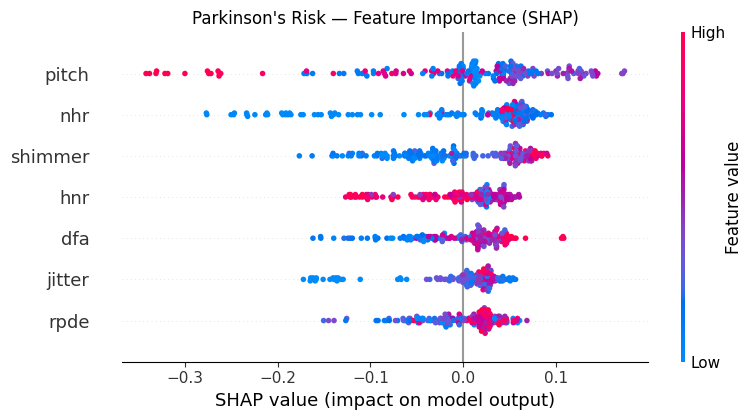

✅ Saved: results/shap_parkinsons.png


In [5]:
import os
os.makedirs("../results", exist_ok=True)

plt.figure()
# Cell 4 - Parkinson's plot fix
shap.summary_plot(
    pk_shap_values[:, :, 1] if pk_shap_values.ndim == 3 else pk_shap_values,
    X_pk_imp_df,
    feature_names=pk_feature_cols,
    show=False
)
plt.title("Parkinson's Risk — Feature Importance (SHAP)")
plt.tight_layout()
plt.savefig("../results/shap_parkinsons.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: results/shap_parkinsons.png")

In [6]:
resp_feature_cols = [
    "pitch", "spectral_centroid", "zcr",
    "jitter", "shimmer", "hnr",
    "mfcc_1","mfcc_2","mfcc_3","mfcc_4","mfcc_5","mfcc_6","mfcc_7",
    "mfcc_8","mfcc_9","mfcc_10","mfcc_11","mfcc_12","mfcc_13"
]

df_resp = pd.read_csv("../data/voice_features/voice_dataset_labeled_full.csv")
X_resp = df_resp[resp_feature_cols].dropna()
X_resp_imp = resp_imputer.transform(X_resp)
X_resp_imp_df = pd.DataFrame(X_resp_imp, columns=resp_feature_cols)

resp_explainer = shap.TreeExplainer(resp_model)
resp_shap_values = resp_explainer.shap_values(X_resp_imp_df)

print("✅ Respiratory SHAP explainer ready")

✅ Respiratory SHAP explainer ready


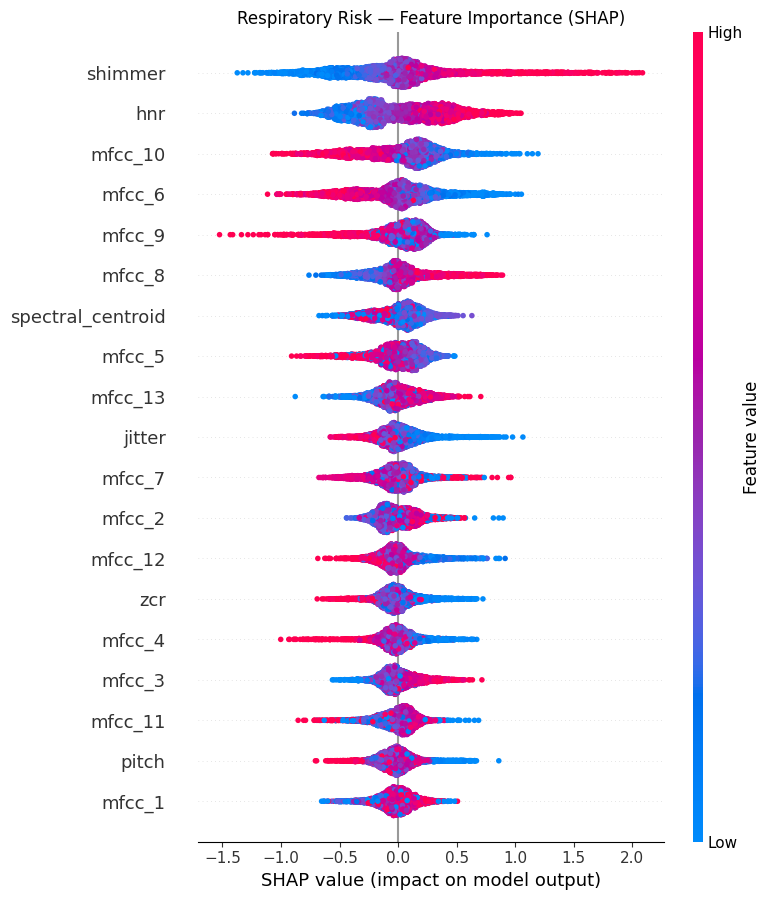

✅ Saved: results/shap_respiratory.png


In [7]:
import os
os.makedirs("../results", exist_ok=True)

plt.figure()
# Cell 6 - Respiratory plot fix
shap.summary_plot(
    resp_shap_values[:, :, 1] if resp_shap_values.ndim == 3 else resp_shap_values,
    X_resp_imp_df,
    feature_names=resp_feature_cols,
    show=False
)
plt.title("Respiratory Risk — Feature Importance (SHAP)")
plt.tight_layout()
plt.savefig("../results/shap_respiratory.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: results/shap_respiratory.png")

In [8]:
def explain_prediction(audio_path):
    features = extract_features(audio_path)

    RPDE_MEAN = 0.498
    DFA_MEAN  = 0.718

    # ── Parkinson's ─────────────────────────────────
    pk_input = pd.DataFrame([{
        "pitch":   features["pitch"],
        "hnr":     features["hnr"],
        "jitter":  features["jitter"],
        "shimmer": features["shimmer"],
        "nhr":     1 - (features["hnr"] / (features["hnr"] + 1)),
        "rpde":    RPDE_MEAN,
        "dfa":     DFA_MEAN
    }])
    pk_imp     = pk_imputer.transform(pk_input)
    pk_imp_df  = pd.DataFrame(pk_imp, columns=pk_feature_cols)
    pk_shap    = pk_explainer.shap_values(pk_imp_df)

    # shape (1,7,2) → take class 1, sample 0
    pk_vals = pk_shap[0, :, 1] if pk_shap.ndim == 3 else pk_shap[0]

    print("\n🧠 Parkinson's — Top driving features:")
    pk_contrib = pd.Series(pk_vals, index=pk_feature_cols)
    pk_contrib = pk_contrib.reindex(pk_contrib.abs().sort_values(ascending=False).index)
    for feat, val in pk_contrib.items():
        direction = "↑ increases risk" if val > 0 else "↓ decreases risk"
        print(f"  {feat:<22} {val:+.4f}  {direction}")

    # ── Respiratory ──────────────────────────────────
    resp_input    = pd.DataFrame([features])[resp_feature_cols]
    resp_imp      = resp_imputer.transform(resp_input)
    resp_imp_df   = pd.DataFrame(resp_imp, columns=resp_feature_cols)
    resp_shap     = resp_explainer.shap_values(resp_imp_df)

    resp_vals = resp_shap[0, :, 1] if resp_shap.ndim == 3 else resp_shap[0]

    print("\n🫁 Respiratory — Top driving features:")
    resp_contrib = pd.Series(resp_vals, index=resp_feature_cols)
    resp_contrib = resp_contrib.reindex(resp_contrib.abs().sort_values(ascending=False).index)
    for feat, val in resp_contrib.items():
        direction = "↑ increases risk" if val > 0 else "↓ decreases risk"
        print(f"  {feat:<22} {val:+.4f}  {direction}")

# Test it
explain_prediction("../data/Coswara-Data/20210816/20210816/9hXEs9OejdVxG6JJGCyKQpqVvy43/counting-normal.wav")


🧠 Parkinson's — Top driving features:
  pitch                  -0.3419  ↓ decreases risk
  shimmer                +0.0630  ↑ increases risk
  nhr                    +0.0408  ↑ increases risk
  jitter                 +0.0343  ↑ increases risk
  rpde                   +0.0211  ↑ increases risk
  dfa                    +0.0199  ↑ increases risk
  hnr                    +0.0118  ↑ increases risk

🫁 Respiratory — Top driving features:
  mfcc_6                 +0.6549  ↑ increases risk
  mfcc_10                +0.3003  ↑ increases risk
  hnr                    +0.2989  ↑ increases risk
  shimmer                +0.2630  ↑ increases risk
  mfcc_9                 +0.2563  ↑ increases risk
  mfcc_3                 +0.2451  ↑ increases risk
  mfcc_7                 +0.2276  ↑ increases risk
  spectral_centroid      +0.2145  ↑ increases risk
  mfcc_5                 +0.1668  ↑ increases risk
  jitter                 -0.1521  ↓ decreases risk
  pitch                  -0.1223  ↓ decreases risk
  mf

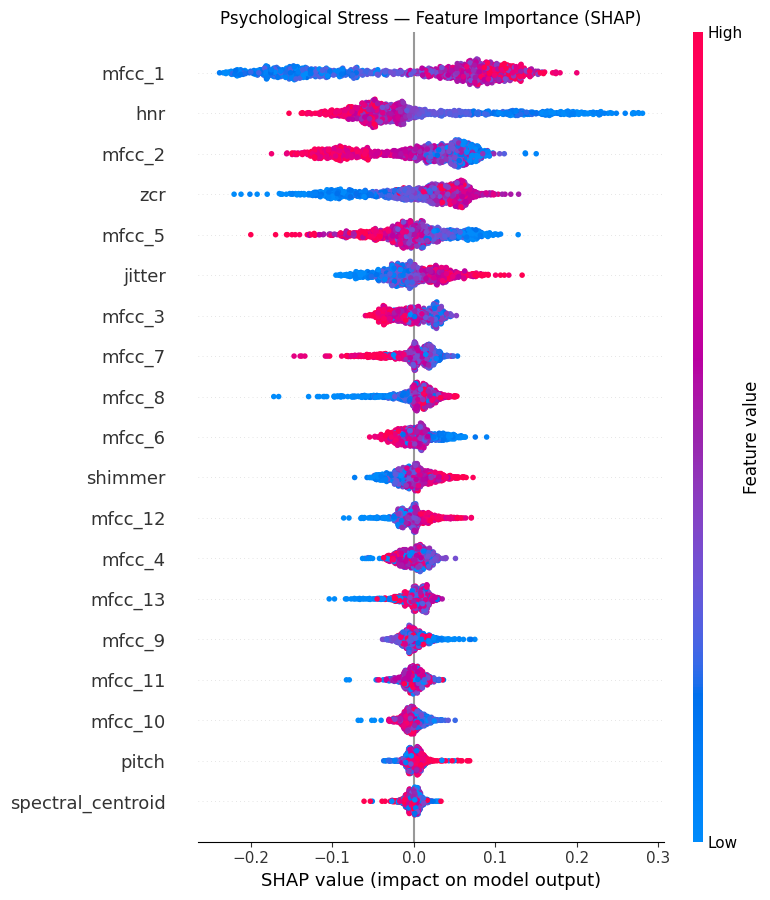

Saved: results/shap_stress.png


In [9]:
df_stress = pd.read_csv("../data/voice_features/stress_dataset.csv").dropna()
X_stress = df_stress[resp_feature_cols]
X_stress_imp = resp_imputer.transform(X_stress)
X_stress_imp_df = pd.DataFrame(X_stress_imp, columns=resp_feature_cols)

stress_explainer = shap.TreeExplainer(stress_model)
stress_shap_values = stress_explainer.shap_values(X_stress_imp_df)

plt.figure()
shap.summary_plot(
    stress_shap_values[:,:,1] if stress_shap_values.ndim == 3 else stress_shap_values,
    X_stress_imp_df,
    feature_names=resp_feature_cols,
    show=False
)
plt.title("Psychological Stress — Feature Importance (SHAP)")
plt.tight_layout()
plt.savefig("../results/shap_stress.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/shap_stress.png")

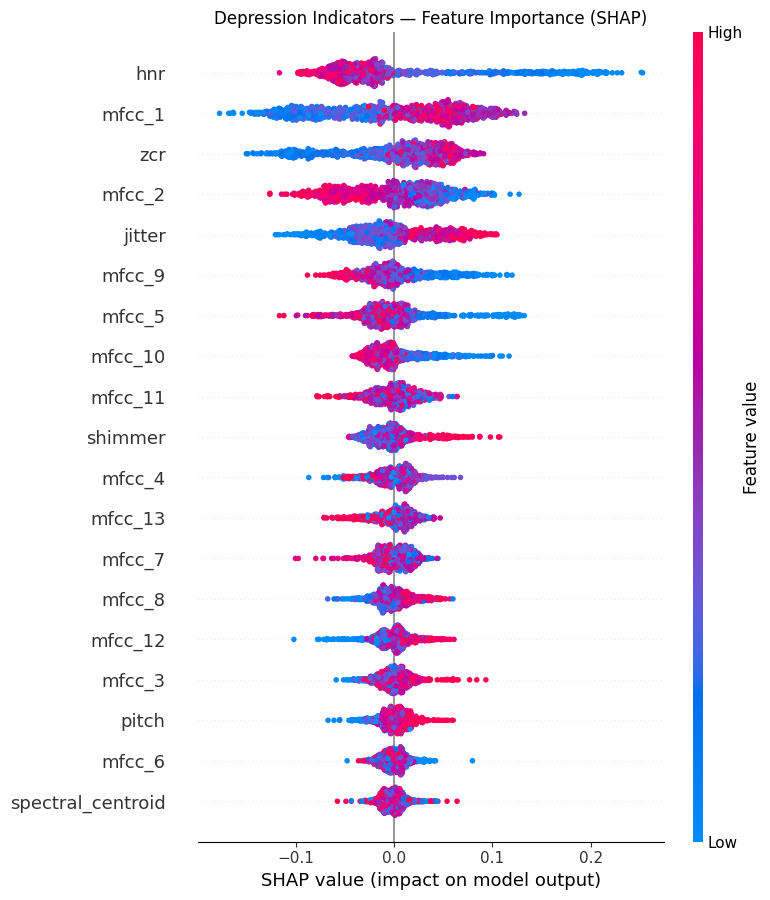

Saved: results/shap_depression.png


In [10]:
df_depr = pd.read_csv("../data/voice_features/depression_dataset.csv").dropna()
X_depr = df_depr[resp_feature_cols]
X_depr_imp = resp_imputer.transform(X_depr)
X_depr_imp_df = pd.DataFrame(X_depr_imp, columns=resp_feature_cols)

depr_explainer = shap.TreeExplainer(depr_model)
depr_shap_values = depr_explainer.shap_values(X_depr_imp_df)

plt.figure()
shap.summary_plot(
    depr_shap_values[:,:,1] if depr_shap_values.ndim == 3 else depr_shap_values,
    X_depr_imp_df,
    feature_names=resp_feature_cols,
    show=False
)
plt.title("Depression Indicators — Feature Importance (SHAP)")
plt.tight_layout()
plt.savefig("../results/shap_depression.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/shap_depression.png")